<a href="https://colab.research.google.com/github/noodlejacknetwork/WatchYourStep-PHASE-5/blob/main/Copy_of_Disaster_Events_JFeb_24_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#IMPORT STUFF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import randint

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
#UPLOAD CSV DATASET FILE (DISASTER EVENTS 2025)

from google.colab import files, drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/synthetic_disaster_events_2025 (1).csv'
df = pd.read_csv(file_path)
df_raw = df.copy()
pd.options.display.float_format = '{:.2f}'.format
print("============================== DATASET PREVIEW ==============================")
print(df_raw.head(175))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
============================== DATASET PREVIEW ==============================
     event_id      disaster_type     location  latitude  longitude  \
0           1           Wildfire        Chile    -34.68     -71.82   
1           2          Hurricane        India     22.13      78.02   
2           3  Volcanic Eruption        Italy     42.32      11.03   
3           4            Drought        Chile    -33.44     -69.98   
4           5  Volcanic Eruption       Turkey     39.40      37.01   
..        ...                ...          ...       ...        ...   
170       171              Flood        Chile    -37.52     -73.15   
171       172         Earthquake        Japan     34.32     136.01   
172       173          Hurricane        India     22.65      78.29   
173       174          Landslide          USA     37.14     -92.89   
174       175         E

# **PHASE 2**


**STEP 1: DATA CLEANING**


STEP 1.1 - Handle Missing Values

In [19]:
# Identify columns with missing values
print("MISSING VALUES COUNT PER COLUMN:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNUMERICAL COLUMNS: {numerical_cols}")
print(f"CATEGORICAL COLUMNS: {categorical_cols}")

# Remove numerical columns with more than 50% missing data
print("\nMISSING VALUES PERCENTAGE PER COLUMN:")
print((df.isnull().sum() / len(df)) * 100)
missing_threshold = 0.5
cols_to_drop = [col for col in df.columns if df[col].isnull().mean() > missing_threshold]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped columns (>50% missing): {cols_to_drop}")

MISSING VALUES COUNT PER COLUMN:
event_id                       0
disaster_type                  0
location                       0
latitude                       0
longitude                      0
date                           0
severity_level                 0
affected_population            0
estimated_economic_loss_usd    0
response_time_hours            0
aid_provided                   0
infrastructure_damage_index    0
is_major_disaster              0
dtype: int64

NUMERICAL COLUMNS: ['event_id', 'latitude', 'longitude', 'severity_level', 'affected_population', 'estimated_economic_loss_usd', 'response_time_hours', 'infrastructure_damage_index', 'is_major_disaster']
CATEGORICAL COLUMNS: ['disaster_type', 'location', 'date', 'aid_provided']

MISSING VALUES PERCENTAGE PER COLUMN:
event_id                      0.00
disaster_type                 0.00
location                      0.00
latitude                      0.00
longitude                     0.00
date                          0

STEP 1.2 - HANDLE OUTLIERS

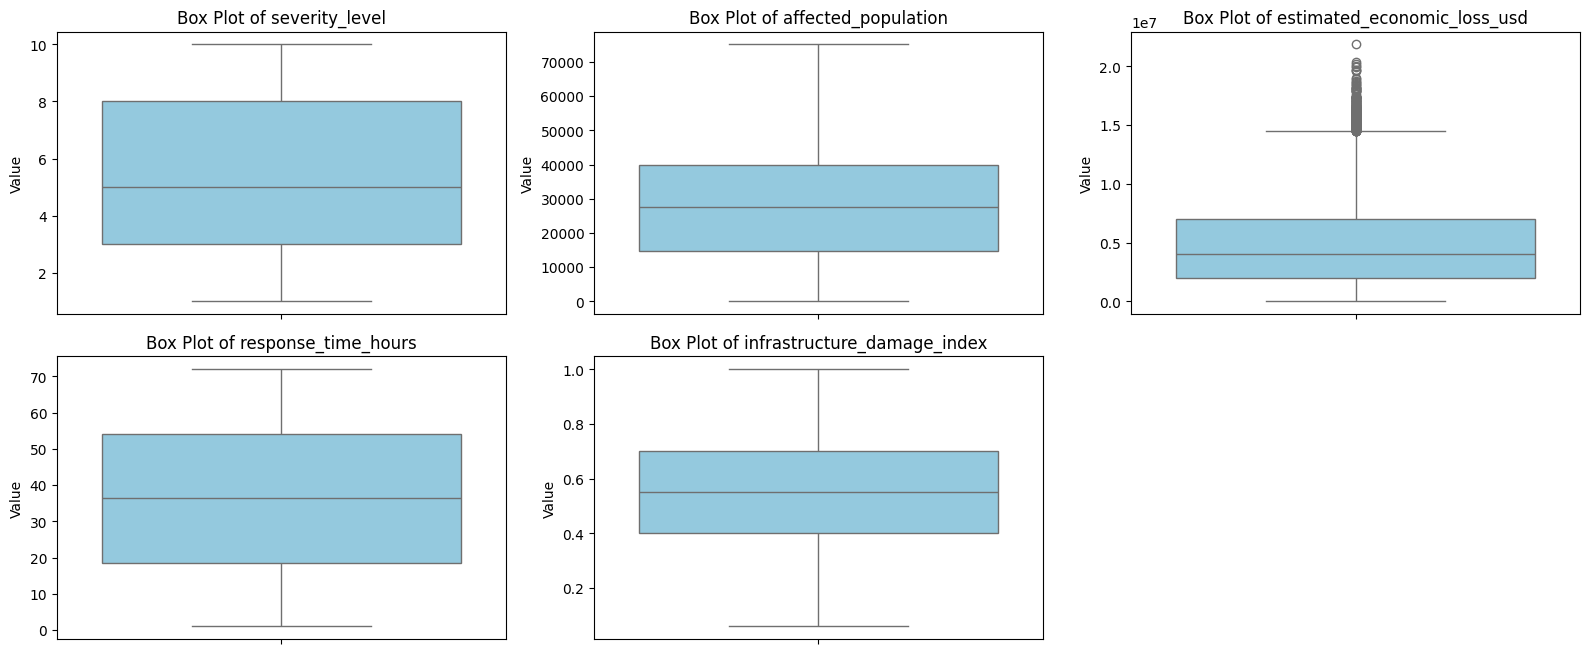

In [20]:
# IDENTIFYING OUTLIERS USING BOX PLOTS
cols_to_plot = ['severity_level', 'affected_population', 'estimated_economic_loss_usd',
                'response_time_hours', 'infrastructure_damage_index']

# Set up the figure and axes
plt.figure(figsize=(16, 10))

# Create boxplots for each column
for i, col in enumerate(cols_to_plot):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.ylabel('Value')

plt.tight_layout()

In [21]:
# DROPPING IRRELEVANT DATA
if 'event_id' in df.columns:
    df.drop(columns=['event_id'], inplace=True)

print("============================= CLEANED DATASET PREVIEW ==============================")
print(df.head(175))

============================= CLEANED DATASET PREVIEW ==============================
         disaster_type     location  latitude  longitude        date  \
0             Wildfire        Chile    -34.68     -71.82  2025-08-27   
1            Hurricane        India     22.13      78.02  2023-05-29   
2    Volcanic Eruption        Italy     42.32      11.03  2023-01-15   
3              Drought        Chile    -33.44     -69.98  2024-02-08   
4    Volcanic Eruption       Turkey     39.40      37.01  2023-12-23   
..                 ...          ...       ...        ...         ...   
170              Flood        Chile    -37.52     -73.15  2025-08-26   
171         Earthquake        Japan     34.32     136.01  2025-02-03   
172          Hurricane        India     22.65      78.29  2025-07-11   
173          Landslide          USA     37.14     -92.89  2023-10-12   
174         Earthquake  Philippines     14.85     124.15  2023-08-02   

     severity_level  affected_population  estimate

**STEP 2: DATA TRANSFORMATION**

STEP 2.1 - Normalize Numerical Features

In [22]:
# APPLYING MIN-MAX SCALING TO NUMERICAL FEATUERS
# Update numeric list (excluding the target column)
exclude_from_scale = ['is_major_disaster']
scale_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_from_scale]

# Initialize MinMaxScaler (Default range is 0 to 1)
scaler = MinMaxScaler()

# Apply the scaling
df[scale_cols] = scaler.fit_transform(df[scale_cols])

STEP 2.2 - Encode Categorical Features

In [23]:
# Label encoding for binary variables
if 'aid_provided' in df.columns:
    le = LabelEncoder()
    df['aid_provided'] = le.fit_transform(df['aid_provided'].astype(str))

# Label encoding for categorical variables (One-Hot Encoding)
cols_to_ohe = ['disaster_type', 'location']
cols_to_ohe = [c for c in cols_to_ohe if c in df.columns]
df = pd.get_dummies(df, columns=cols_to_ohe, drop_first=True, dtype=int)

STEP 2.3 - Feature Engineering


In [24]:
# Feature Engineering: Date processing
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['date'] = df['date'].fillna(df['date'].mode()[0])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df.drop(columns=['date'], inplace=True)

print("============================== TRANSFORMED DATASET PREVIEW ==============================")
print(df.head(10))

============================== TRANSFORMED DATASET PREVIEW ==============================
   latitude  longitude  severity_level  affected_population  \
0      0.09       0.12            0.78                 0.41   
1      0.71       0.73            0.44                 0.39   
2      0.93       0.46            0.67                 0.46   
3      0.11       0.13            0.78                 0.42   
4      0.90       0.56            0.78                 0.62   
5      0.44       0.87            0.89                 0.66   
6      0.69       0.73            0.67                 0.45   
7      0.88       0.98            0.67                 0.46   
8      0.92       0.55            0.33                 0.11   
9      0.84       0.02            0.33                 0.28   

   estimated_economic_loss_usd  response_time_hours  aid_provided  \
0                         0.13                 0.06             1   
1                         0.27                 0.61             0   
2        

**STEP 3: DATA REDUCTION METHODS**

STEP 3.1 - Dimensionality Reduction

In [25]:
#code before

#code after ()

# 1. Log Transformation (accoridng toh to our updated phase 2 report)
# For da skewness of the population data
df['affected_population'] = np.log1p(df['affected_population'])

# 2. Prepare features for PCA
pca_features = ['severity_level', 'affected_population', 'infrastructure_damage_index']
x_pca = df[pca_features]

# 3. Scaling for PCA (PCA requires Standardized data)
scaler_pca = StandardScaler()
x_pca_scaled = scaler_pca.fit_transform(x_pca)

# 4. Apply PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(x_pca_scaled)

# 5. Add PCA scores to Main Dataframe
df['total_impact_score'] = pcs[:, 0]
df['response_pattern_score'] = pcs[:, 1]

print("\nPCA Complete. \nNew features 'total_impact_score' and 'response_pattern_score' added.")



PCA Complete. 
New features 'total_impact_score' and 'response_pattern_score' added.



Top correlations with target:
is_major_disaster                  1.00
severity_level                     0.85
total_impact_score                 0.81
affected_population                0.74
estimated_economic_loss_usd        0.58
infrastructure_damage_index        0.57
location_India                     0.01
disaster_type_Landslide            0.00
location_USA                       0.00
disaster_type_Earthquake           0.00
disaster_type_Volcanic Eruption    0.00
disaster_type_Hurricane            0.00
location_Indonesia                 0.00
month                              0.00
year                              -0.00
response_time_hours               -0.00
disaster_type_Wildfire            -0.00
location_Italy                    -0.00
location_Philippines              -0.00
location_Turkey                   -0.00
day_of_week                       -0.01
location_Japan                    -0.01
longitude                         -0.01
latitude                          -0.01
disaster_

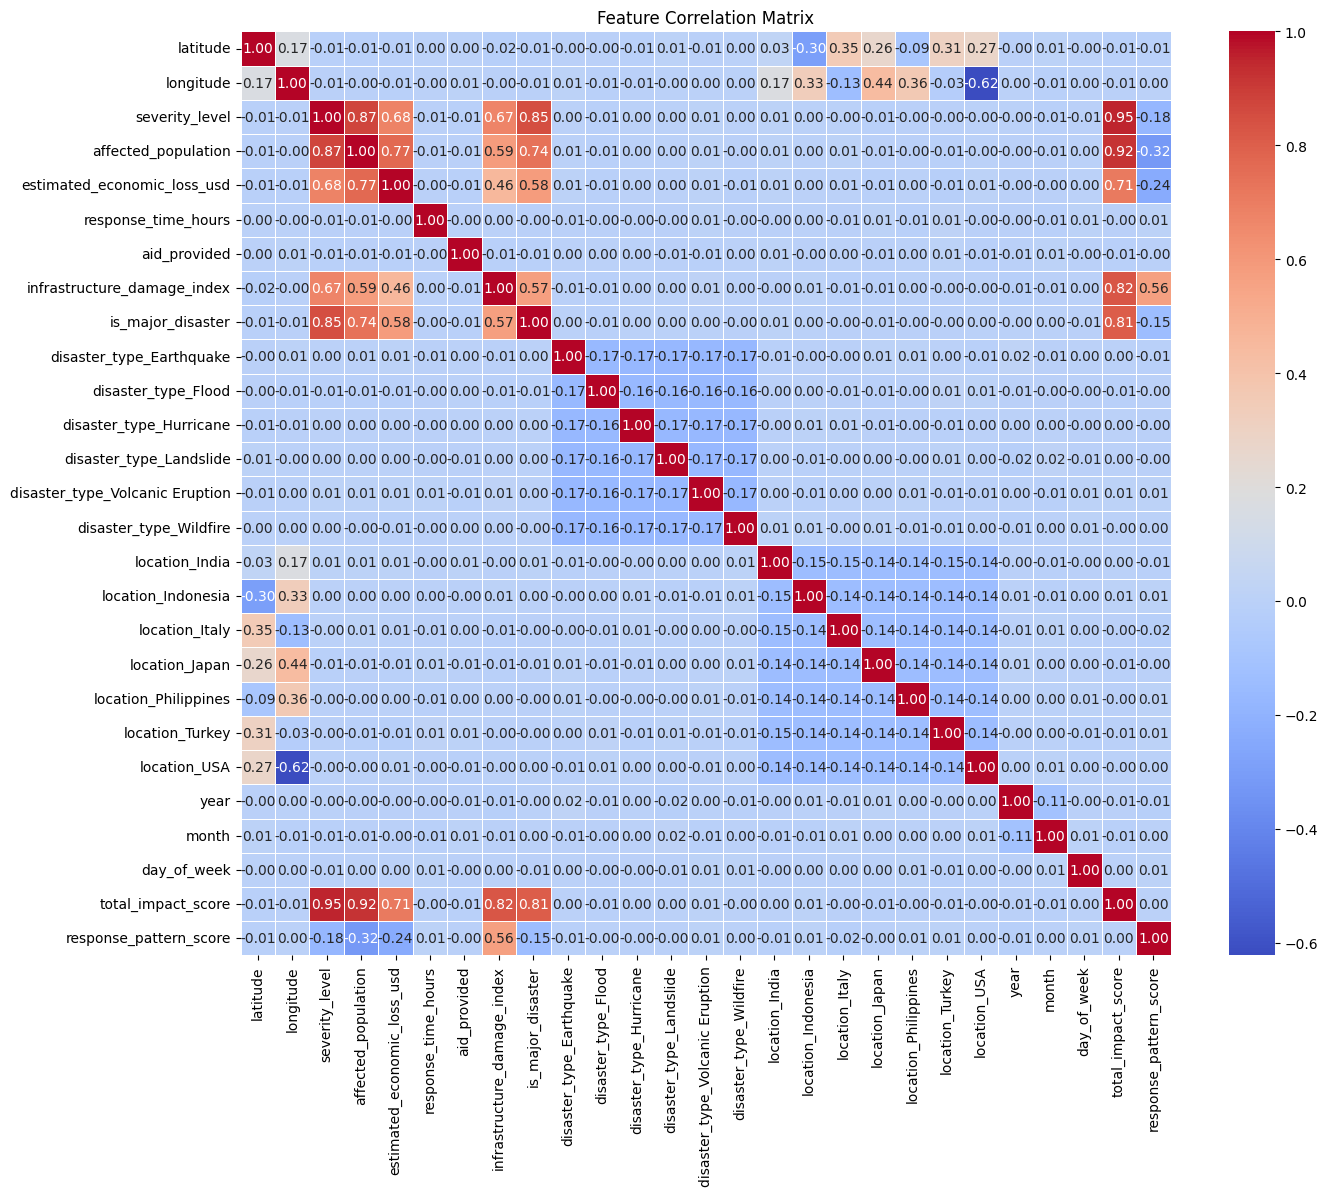

In [26]:
# Correlation Analysis
correlation_matrix = df.corr()
top_corr_features = correlation_matrix['is_major_disaster'].sort_values(ascending=False)
print("\nTop correlations with target:")
print(top_corr_features)

# Heat Map
corr = df.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# **PHASE 3**

Tuning Random Forest model... (Pa wait lng po.)

================ EVALUATION REPORT ================
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 6, 'n_estimators': 260}
Overall Accuracy: 0.9505

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2445
           1       0.93      0.94      0.94      1555

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



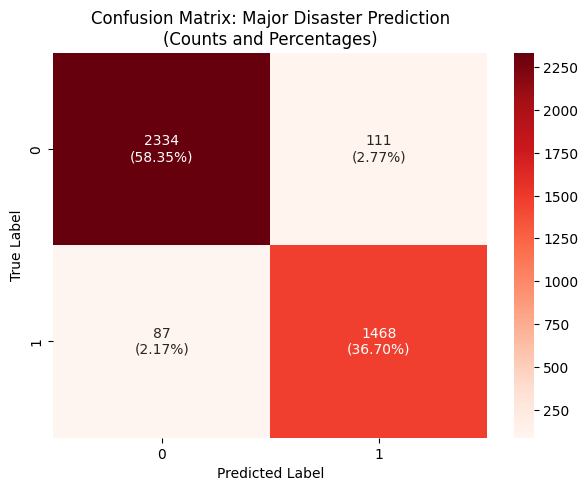

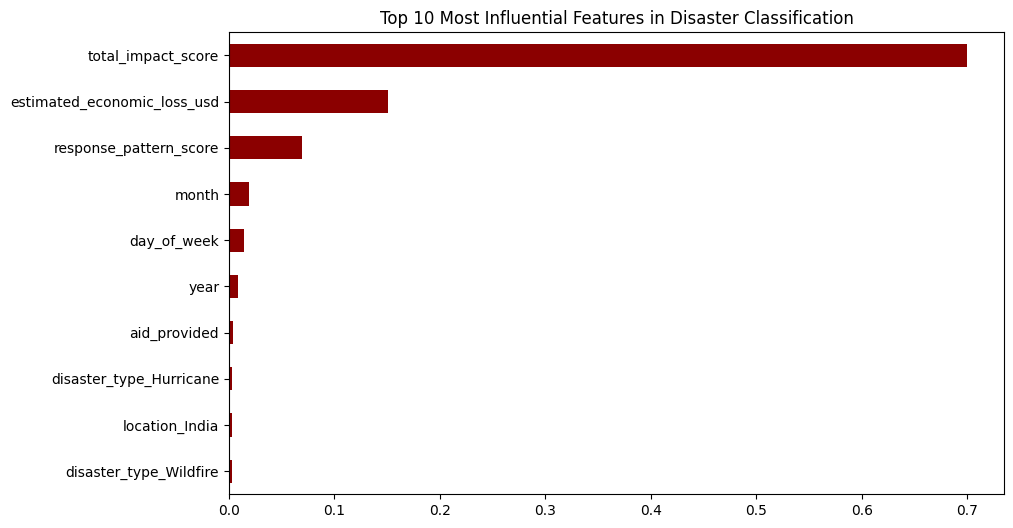


Model saved as 'disaster_model_2025.joblib' 
 this is for deliverable 2, para ma reuse this model file for future predictions


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import randint

# Scikit-learn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# =========================================================
# PHASE 3: MODEL SELECTION, TRAINING & EVALUATION
# =========================================================


# 1. Feature Selection (Base sa ating updated phase 2 report)
features_to_use = [
    'total_impact_score', 'response_pattern_score',
    'estimated_economic_loss_usd', 'aid_provided',
    'year', 'month', 'day_of_week'
]
# Add the One-Hot Encoded columns automatically
ohe_cols = [c for c in df.columns if 'disaster_type_' in c or 'location_' in c]
features_to_use.extend(ohe_cols)

X = df[features_to_use]
y = df['is_major_disaster']

# 2. Train-Test Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Model Training with Hyperparameter Tuning (Step 2 & 4 of Canvas Instructions)
# We use RandomizedSearch to find the best 'n_estimators' and 'max_depth'
rf = RandomForestClassifier(random_state=42)
param_dist = {
    "n_estimators": randint(100, 300),
    "max_depth": [10, 20, 30, None],
    "min_samples_split": randint(2, 11),
    "criterion": ["gini", "entropy"]
}

print("Tuning Random Forest model... (Pa wait lng po.)")
random_search = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

# 4. Evaluation (Step 3 of Canvas Instructions)
y_pred = best_model.predict(X_test)

print("\n================ EVALUATION REPORT ================")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

"""
# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix: Major Disaster Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print()
"""

# =========================================================
# UPDATED CONFUSION MATRIX (With Percentages)
# =========================================================

# 1. Generate the standard confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Calculate percentages (each cell divided by the sum of all cells)
cm_percent = cm.astype('float') / cm.sum()

# 3. Create custom labels that show "Count (Percentage%)"
# This creates a text array to overlay on the heatmap
labels = [f"{count}\n({perc:.2%})" for count, perc in zip(cm.flatten(), cm_percent.flatten())]
labels = np.array(labels).reshape(2,2) # Reshape to match the 2x2 matrix

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=labels, fmt="", cmap='Reds', cbar=True)

plt.title("Confusion Matrix: Major Disaster Prediction\n(Counts and Percentages)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 5. Model Interpretation: Feature Importance (Step 5 of Canvas Instructions)
importances = best_model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).nlargest(10)
plt.figure(figsize=(10,6))
feat_importances.plot(kind='barh', color='darkred')
plt.title("Top 10 Most Influential Features in Disaster Classification")
plt.gca().invert_yaxis()
plt.show()

# 6. Save the Model (Deliverable 2, )
joblib.dump(best_model, 'disaster_model_2025.joblib')
print("\nModel saved as 'disaster_model_2025.joblib' \n this is for deliverable 2, para ma reuse this model file for future predictions")

ADDITIONAL CODE, THIS IS TO GENERATE THE REQUIRED FILE OF "CLEANED DATA SET" so download it.

In [28]:
# to generate the cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("✅ 'cleaned_dataset.csv' has been created. Download it from the folder icon on the left!")

✅ 'cleaned_dataset.csv' has been created. Download it from the folder icon on the left!


--- END ---